<a href="https://colab.research.google.com/github/PujanPandey07/Deep-Learning-/blob/main/Pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

## puting Tensors and models on gpu


In [2]:
tensor=torch.tensor([1,2,3])
print(tensor,tensor.device)

tensor([1, 2, 3]) cpu


## moving tensor to gpu enviroment if available


In [3]:
device ='cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
print(device)

cpu


In [5]:
tensor_on_gpu= tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3])

In [6]:
#tensor back to numpy is not possible in gpu enviroment
tensor_back_to_cpu=tensor_on_gpu.cpu().numpy()
tensor_back_to_cpu


array([1, 2, 3])

what are we covering?= { 1: "data(prepare and load)"
                           2:"build model"
                           3: "Fitting the model to data(training)"
                           4: "Making predictions and evaluating a model(Inference)"
                           5: "Saving and loading a model"
                           6: "putting it all togther"}

In [7]:
from torch import nn #nn contains all building blocks of pytorch

In [8]:
import matplotlib.pyplot as plt

## Data Preparing and loading
Data can be anything like image tesxt video etc

Machine learing is basically two things:
 1.representing data in numerical representation
 2.finding patterns based on that representations

In [9]:
#lineaar regresssion formula
weight=0.7
bias=0.2

In [10]:
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
X[:10]

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])

In [11]:
y[:10]

tensor([[0.2000],
        [0.2140],
        [0.2280],
        [0.2420],
        [0.2560],
        [0.2700],
        [0.2840],
        [0.2980],
        [0.3120],
        [0.3260]])

In [12]:
## splitting data into train and test
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [13]:
##visualization of data
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c='b',s=4,label='training data')
  plt.scatter(test_data,test_labels,c='g',s=4,label='test data')
  if predictions is not None:
    plt.scatter(test_data,predictions,c='g',s=4,label='test predictions')


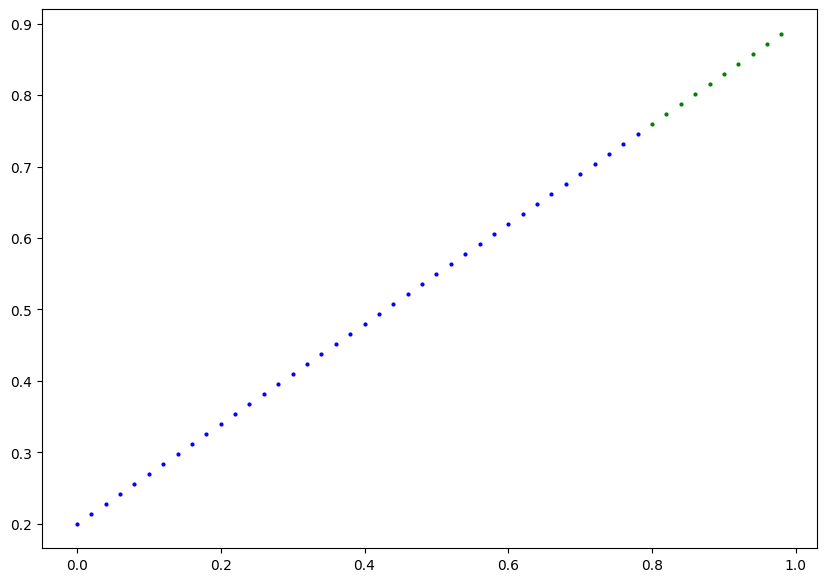

In [14]:
plot_predictions()


## Building our first pytorch model for linear regression

In [15]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float, device=device))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float, device=device))

    # This is the missing piece!
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The linear regression formula: y = weights * x + bias
        return self.weights * x + self.bias

In [16]:
torch.manual_seed(43)

In [17]:
model_0=LinearRegressionModel()
model_0

LinearRegressionModel()

In [18]:
list(model_0.parameters())

[Parameter containing:
 tensor([-0.6484], requires_grad=True),
 Parameter containing:
 tensor([-0.7058], requires_grad=True)]

In [19]:
model_0.state_dict()

OrderedDict([('weights', tensor([-0.6484])), ('bias', tensor([-0.7058]))])

In [20]:
#make predictions with data
with torch.inference_mode():
  # Move X_test to the same device as the model
  y_preds_new=model_0(X_test.to(device))
y_preds_new

tensor([[-1.2246],
        [-1.2375],
        [-1.2505],
        [-1.2635],
        [-1.2764],
        [-1.2894],
        [-1.3024],
        [-1.3153],
        [-1.3283],
        [-1.3413]])

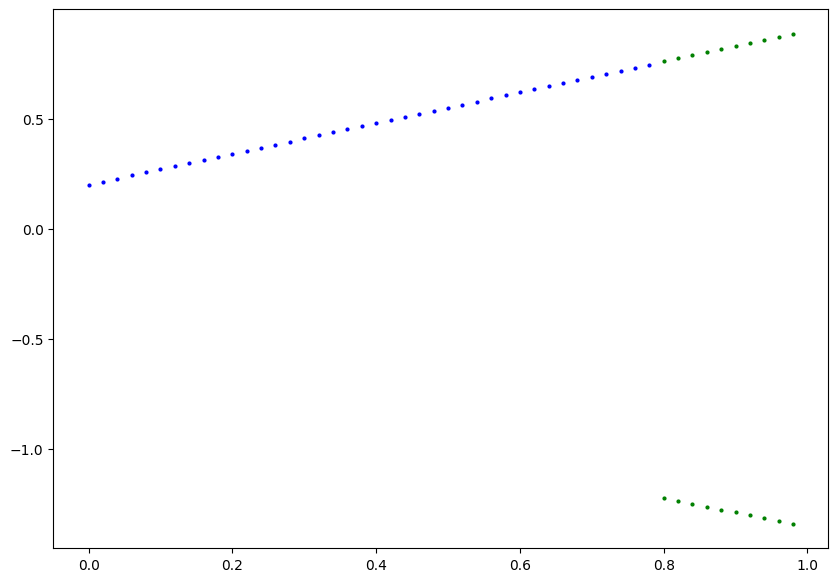

In [21]:
plot_predictions(test_data=X_test.cpu(), predictions=y_preds_new.cpu())

## Training Model

Model training is done to shift from unknown and random parameters to a required or known parameters.
* One way to do it is by using loss functions

In [22]:
## Setup a loss function
loss_fn=nn.L1Loss()
## setup a optimizer
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


## Building a testing loop and Training loop in pytorch
Couple of things we need ina training loop:
1. loop through the data
2. Forward pass
3. calculate the loss
4. optimizer zero grad
5. loss backward(back propagation)
6. Optimizer step(gradient descent)

In [23]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 1.431717872619629 | MAE Test Loss: 1.9712083339691162 
Epoch: 10 | MAE Train Loss: 0.29357343912124634 | MAE Test Loss: 0.6499983668327332 
Epoch: 20 | MAE Train Loss: 0.14098013937473297 | MAE Test Loss: 0.3254033327102661 
Epoch: 30 | MAE Train Loss: 0.10655883699655533 | MAE Test Loss: 0.24267926812171936 
Epoch: 40 | MAE Train Loss: 0.0722041130065918 | MAE Test Loss: 0.15995509922504425 
Epoch: 50 | MAE Train Loss: 0.03782393038272858 | MAE Test Loss: 0.08409995585680008 
Epoch: 60 | MAE Train Loss: 0.03943648189306259 | MAE Test Loss: 0.06502307951450348 
Epoch: 70 | MAE Train Loss: 0.03943648189306259 | MAE Test Loss: 0.06502307951450348 
Epoch: 80 | MAE Train Loss: 0.03943648189306259 | MAE Test Loss: 0.06502307951450348 
Epoch: 90 | MAE Train Loss: 0.03943648189306259 | MAE Test Loss: 0.06502307951450348 


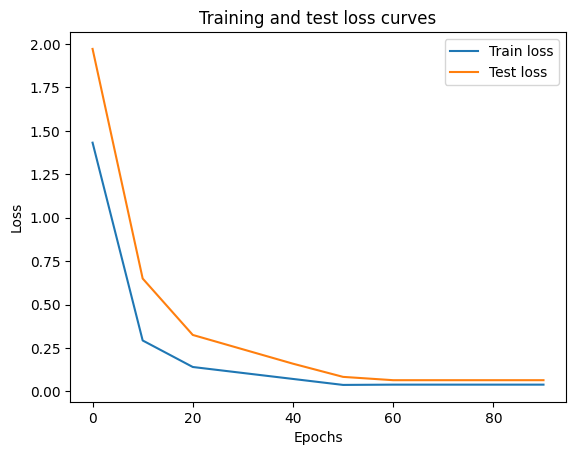

In [24]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [25]:
model_0.state_dict()
#

OrderedDict([('weights', tensor([0.6395])), ('bias', tensor([0.1842]))])

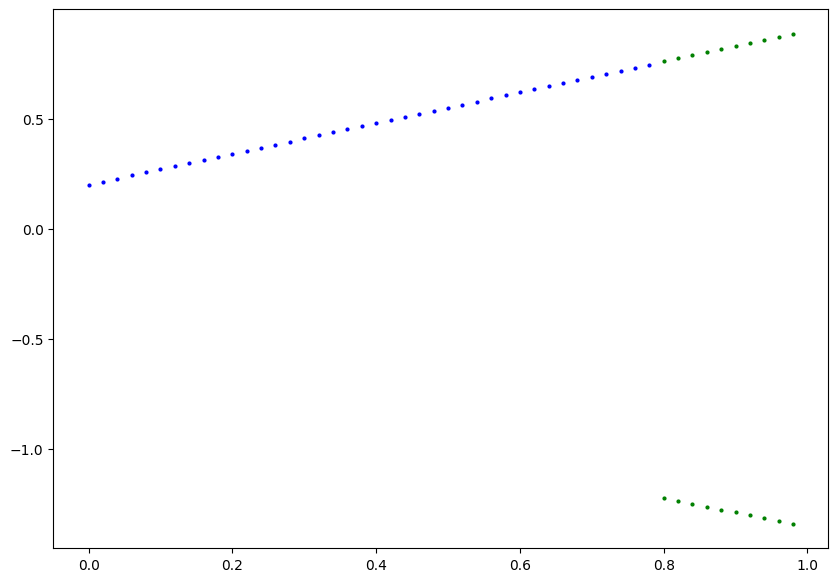

In [26]:
plot_predictions(predictions=y_preds_new.cpu())

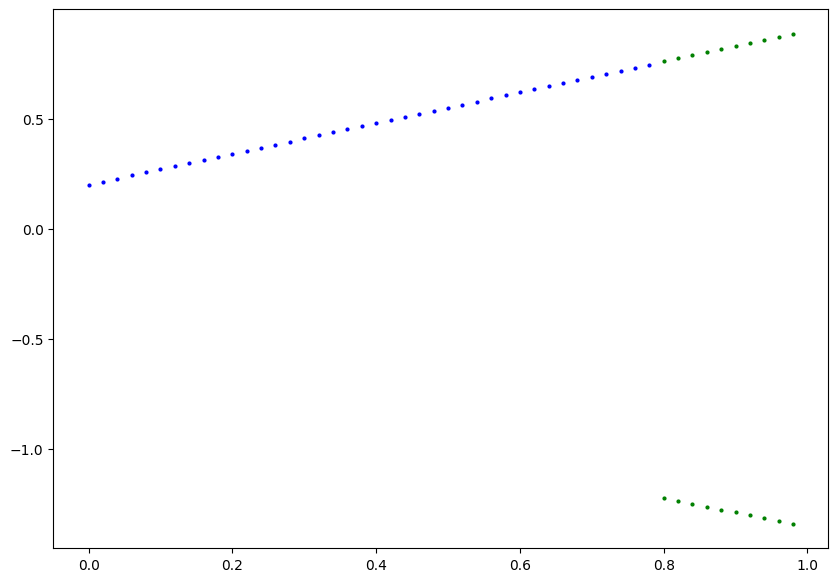

In [27]:
plot_predictions(predictions=y_preds_new.cpu())




```
`# This is formatted as code`
```

## Saving our models in pytorch
There are three main methods:
1. torch.save() --uses pythons pickel model
2. torch.load() --allows you to load a saved PyTorch object
3. torch.nn.module.load_state_dict()--allows to load models saved dictionary

In [32]:
from pathlib import Path
#create model directory
MODEL_PATH=Path('models')
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME="pytorch_workflow.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME
MODEL_SAVE_PATH
#saving
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)

In [34]:
#loading saved model
torch.load(MODEL_SAVE_PATH)

OrderedDict([('weights', tensor([0.6395])), ('bias', tensor([0.1842]))])